# Info Extraction
- Fetch key info from API
- Get Financial Statements and data related to the past 30 days
- Get Quarterly Data

## Verify
- Statements are released on the same day
- Determine analysis period for stock_hist_info()

## Improvement
- FMP contains stats from anaylist maybe we could also use those

In [1]:
from pathlib import Path
import pandas as pd
import requests

In [2]:
import yaml

class Config:

    @staticmethod
    def setup():
        # Load config from YAML file
        with open('config.yaml', 'r') as file:
            config = yaml.safe_load(file)

        # Extract the directory path variable
        data_directory = config['variables']['data_directory']

        # Replace placeholders in the config
        config = Config.replace_placeholders(config, {'data_directory': data_directory})
        
        # Set up directory paths in the Dir class
        Dir.ROOT = Path.cwd()  # Corrected to move one directory up 
        print("if bug do Dir.ROOT = Path.cwd().parent")
        print(Dir.ROOT)
        Dir.RAW = Dir.ROOT / config['paths']['data']['directories']['raw']['path']
        Dir.EXTERNAL = Dir.ROOT / config['paths']['data']['directories']['external']['path']
        Dir.INTERIM = Dir.ROOT / config['paths']['data']['directories']['interim']['path']
        Dir.PROCESSED = Dir.ROOT / config['paths']['data']['directories']['processed']['path']

        # Assigning CSV file names based on the YAML structure
        CSV.SP500 = config['files']['external']['sp500']['name']
        CSV.KEY_METRIC = config['files']['raw']['metric']['name']
        CSV.RATIOS = config['files']['raw']['ratios']['name']
        CSV.STOCK_HIST = config['files']['raw']['stock']['name']
        CSV.DATABASE = config['files']['processed']['database']['name']

        print("Configuration setup complete.")


    def replace_placeholders(config, variable_values):
        # Iterate over directories and replace the placeholder with the actual value
        for section in config['paths']['data']['directories'].values():
            section['path'] = section['path'].format(**variable_values)
        return config


class Dir:
    ROOT=""
    RAW =""
    INTERIM="" 
    PROCESSED="" 
    EXTERNAL=""


# file names
class CSV:
    SP500 = ''
    KEY_METRIC = ''
    RATIOS = ''
    STOCK_HIST = ''
    GROWTH = '' # basically merge of key_metrics and ratios csv
    DATABASE = ''



In [8]:
class Test:
    @staticmethod
    def limit_tickers(index,limit):
        return index >= limit

In [81]:
class API:

    CALL_LIMIT_PER_MIN = 750
    KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"
    BASE_URL = "https://financialmodelingprep.com/stable/"
    
    # Might need to track number of API CALLS PER MINUTE
    
    def fetch(endpoint="", query="",verbose=False):
        url = f"{API.BASE_URL}{endpoint}?{query}&apikey={API.KEY}"
        if verbose:
            print(f"\trequest url:{url}")
        response = requests.get(url)
        json_response = response.json()
        return pd.DataFrame(json_response)
           
    def fetch_sp500_constituent_info():
        df_constituent_full_info = API.fetch("sp500-constituent")
        df_constituent_full_info.set_index('symbol', inplace=True)
        df_constituent_light_info = df_constituent_full_info[['sector','subSector']] 
        return df_constituent_light_info

    # The "date" in the responses of fetch_ticker_key_metrics() and fetch_ticker_financial_ratios() represents the end date of the period the financial statement covers 
    def fetch_ticker_key_metrics(symbol,period="quarter"):
        endpoint = "key-metrics"
        query = f"symbol={symbol}&period={period}&limit=400"
        df_key_metrics = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_key_metrics)

    def fetch_ticker_financial_ratios(symbol,period="quarter"):
        endpoint = "ratios"
        query = f"symbol={symbol}&period={period}&limit=400"
        df_financial_ratio = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_financial_ratio)

    # For fetch price --> get the full list and then process in order to reduce the number of API calls
    def fetch_ticker_hist_price(symbol):
        endpoint = "historical-price-eod/full"
        query = f"symbol={symbol}"
        df_hist_price = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_hist_price)
    
    def set_index_and_sort(df,index="date"):
        df.set_index('date', inplace=True)
        df.index = pd.to_datetime(df.index)
        df = df.sort_index(ascending=True)
        return df
    
    def sector_list():
        endpoint = "available-sectors"
        df_sector_list = API.fetch(endpoint)
        return df_sector_list
    
    def sector_id():
        df_symbol_sector_subsector = API.fetch_sp500_constituent_info()
        sector_map = dict(zip(API.sector_list()["sector"], API.sector_list().index))
        df_symbol_sector_subsector["sector"] = df_symbol_sector_subsector["sector"].map(sector_map)
        return df_symbol_sector_subsector.reset_index()

In [15]:
import time

class FolderStructure:

    @staticmethod
    def create():
        Dir.ROOT.mkdir(parents=True, exist_ok=True)
        Dir.RAW.mkdir(parents=True, exist_ok=True)
        Dir.EXTERNAL.mkdir(parents=True, exist_ok=True)
        Dir.PROCESSED.mkdir(parents=True, exist_ok=True)
        Dir.INTERIM.mkdir(parents=True, exist_ok=True)
        FolderStructure.download_sp500_constituent_info() # need to be added later


    @staticmethod
    def load_data(testing=False,num_tickers=1,period = 'quarter'):
        #df = FolderStructure.read_external_csv(CSV.SP500)
        df = API.sector_id()
        print("Loading data...")
        past_min = 0
        api_timer = time.time()
        for index,row in df.iterrows():
            curr_minute_calls = index*3 - API.CALL_LIMIT_PER_MIN * past_min
            elapsed = time.time() - api_timer 
            if (curr_minute_calls)>API.CALL_LIMIT_PER_MIN:
                print("---------------------------")
                print("\tPausing data calls")
                time.sleep(60-elapsed)
                print("\tResuming data calls")
                print("---------------------------")
            if (elapsed>60):
                api_timer=time.time()
                past_min+=1

            print(f"\t[{index}/500] - {row['symbol']}" )
            FolderStructure.download_ticker_raw_data(row['symbol'], row['sector'],period)
            if testing and Test.limit_tickers(index,num_tickers):
                break


    @staticmethod
    def read_ticker_csv(stage_dir, symbol, csv_name, index='date'):
        target_dir = stage_dir / 'tickers' / symbol
        target_dir.mkdir(parents=True, exist_ok=True)
        df = pd.read_csv(target_dir / csv_name, index_col=index)
        return df

    @staticmethod
    def write_ticker_csv(df, stage_dir, symbol, csv_name):
        target_dir = stage_dir / 'tickers' / symbol
        target_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(target_dir / csv_name)


    @staticmethod
    def write_interim_csv(df):
        target_dir = Dir.INTERIM
        target_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(target_dir / CSV.DATABASE)
        
    @staticmethod
    def write_interim_ticker_csv(df,symbol, csv_name, index='date'):
        target_dir = Dir.INTERIM / 'tickers'
        target_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(target_dir / csv_name)

    @staticmethod
    def read_raw_ticker_csv(symbol, csv_name):
        return FolderStructure.read_ticker_csv(Dir.RAW, symbol, csv_name)

    @staticmethod
    def read_interim_ticker_csv(symbol, csv_name, index='date'):
        target_dir = Dir.INTERIM / 'tickers'
        df = pd.read_csv(target_dir / csv_name, index_col=index) # WARNING might cause issues --> rows with same indexes
        return df
    
    @staticmethod
    def read_interim_csv(csv_name, index='date'):
        target_dir = Dir.INTERIM
        df = pd.read_csv(target_dir / csv_name, index_col=index) # WARNING might cause issues --> rows with same indexes
        return df
    
    @staticmethod
    def read_external_csv(csv_name):
        target_dir = Dir.EXTERNAL
        target_dir.mkdir(parents=True, exist_ok=True)
        df = pd.read_csv(target_dir / csv_name)
        return df
    
    @staticmethod
    def read_processed_csv(csv_name):
        target_dir = Dir.PROCESSED
        target_dir.mkdir(parents=True, exist_ok=True)
        df = pd.read_csv(target_dir / csv_name)
        return df

    @staticmethod
    def write_processed_ticker_csv(df, symbol, csv_name):
        FolderStructure.write_ticker_csv(df, Dir.PROCESSED, symbol, csv_name)

    @staticmethod
    def download_sp500_constituent_info():
        df = API.fetch_sp500_constituent_info()
        df = df.sort_values(by='symbol', ascending=True)
        df.to_csv(Dir.EXTERNAL / CSV.SP500)

    @staticmethod
    def download_ticker_raw_data(symbol, sector, period="quarter"):
        parent = Dir.RAW / 'tickers' / symbol
        parent.mkdir(parents=True, exist_ok=True)
        df_stock_hist = API.fetch_ticker_hist_price(symbol)
        df_stock_hist.to_csv(parent / CSV.STOCK_HIST)

        df_key_metrics = API.fetch_ticker_key_metrics(symbol, period)
        df_key_metrics["sector"] = sector
        df_key_metrics.to_csv(parent / CSV.KEY_METRIC)
        
        df_ratios = API.fetch_ticker_financial_ratios(symbol, period)
        df_ratios["sector"] = sector
        df_ratios.to_csv(parent / CSV.RATIOS)

        return df_key_metrics.head()

    @staticmethod
    def process_ticker_data(symbol, period="quarter"):
        raw_dir = Dir.RAW / 'tickers' / symbol
        raw_dir.mkdir(parents=True, exist_ok=True)

        train_dir = Dir.PROCESSED / 'train'
        train_dir.mkdir(parents=True, exist_ok=True)

        test_dir = Dir.PROCESSED / 'test'
        test_dir.mkdir(parents=True, exist_ok=True)


In [4]:
Config.setup()
#FolderStructure.create()
#FolderStructure.load_data()

if bug do Dir.ROOT = Path.cwd().parent
/home/frank-lucas/Repos/portfolio-optimizer
Configuration setup complete.


In [ ]:
class Signals:

    EXCLUDE_COLS = ['symbol','fiscalYear','period','reportedCurrency','sector'] 
    STR_COLS = ['symbol','fiscalYear','period','reportedCurrency'] 

    def construct_features(symbol,period='quarter'):
        df_label = pd.DataFrame({'y':[]})
        df_all_info = Signals.growth_statements_info(symbol,period)
        df_stock = Signals.stock_insight(symbol)
        df_stock.index = pd.to_datetime(df_stock.index)

        df_all_info = df_all_info.merge(df_stock,on='date')

        FolderStructure.write_interim_ticker_csv(df_all_info,symbol,f"{symbol}.csv")

    def growth_statements_info(symbol,period='quarter',num_periods_compared=1):
        
        df_growth_info_raw = FolderStructure.read_raw_ticker_csv(symbol,CSV.KEY_METRIC)
        df_ratios_raw = FolderStructure.read_raw_ticker_csv(symbol,CSV.RATIOS)

        df_ratios_adj = df_ratios_raw.drop(columns=Signals.EXCLUDE_COLS)
        df_growth_info_raw = df_growth_info_raw.merge(df_ratios_adj,on='date')
        
        df_growth_info = df_growth_info_raw[Signals.EXCLUDE_COLS]

        for gap in range(1,num_periods_compared+1):
            df_p_growth = df_growth_info_raw.drop(columns=Signals.EXCLUDE_COLS).pct_change(gap,fill_method=None)
            new_columns_names = [name+"_"+str(gap)+"p" for name in df_p_growth.columns]
            df_p_growth.columns = new_columns_names
            df_growth_info.loc[:,df_p_growth.columns] = df_p_growth
        
        # replace end of period dates by business days since sometimes they are on weekends
        df_growth_info = df_growth_info.reset_index()
        df_growth_info['date'] = pd.to_datetime(df_growth_info['date'])
        df_growth_info['date']= df_growth_info['date'].apply(lambda d: d if d.weekday() < 5 else d - pd.offsets.BDay(1))

        df_growth_info.set_index('date',inplace=True)
  
        # FolderStructure.write_processed_ticker_csv(df_growth_info,symbol,CSV.GROWTH) #TESTING
        return df_growth_info
    
    def stock_insight(symbol): # Determine Analysis Period
        #df_hist_raw = API.fetch_ticker_hist_price(symbol)
        df_hist_raw = FolderStructure.read_raw_ticker_csv(symbol,CSV.STOCK_HIST)

        # For dataframe subtractions collumns must have same names. This is not the case for series
        closing_price = df_hist_raw['close']
        low_price = df_hist_raw['low']
        high_price = df_hist_raw['high']
        volume = df_hist_raw["volume"]

        # Return
        ret_1d = closing_price.pct_change(fill_method=None)
        ret_2d = closing_price.pct_change(2,fill_method=None)
        ret_5d = closing_price.pct_change(5,fill_method=None)
        ret_10d = closing_price.pct_change(10,fill_method=None)
        ret_20d = closing_price.pct_change(20,fill_method=None)
        ret_30d = closing_price.pct_change(30,fill_method=None)
        y = closing_price.pct_change(-5,fill_method=None)

        # Volatility
        vol_5d = closing_price.pct_change().shift(1).rolling(window=5).std()
        vol_10d = closing_price.pct_change().shift(1).rolling(window=10).std()

        # Momentum
        momentum_10d = closing_price - closing_price.shift(10)

        # MFV
        mfm = ((closing_price-low_price) - (high_price-closing_price))/(high_price-low_price)
        mfv = mfm * volume
        ad_line = mfv.cumsum()
        AD_momentum_5d = ad_line.pct_change(5,fill_method=None)
        AD_momentum_10d = ad_line.pct_change(10,fill_method=None)
        AD_momentum_20d = ad_line.pct_change(20,fill_method=None)

        # SMA Ratio
        sma_10 = closing_price.shift(1).rolling(window=10).mean()
        sma_50 = closing_price.shift(1).rolling(window=50).mean()
        sma_ratio = sma_10/sma_50

        # Z-score (20d)
        rolling_mean = closing_price.shift(1).rolling(window=20).mean()
        rolling_std = closing_price.shift(1).rolling(window=20).std()
        z_score_20d = (closing_price - rolling_mean)/rolling_std

        # RSI (14d)
        delta = closing_price.diff()
        gain = delta.where(delta > 0, 0.0)
        loss = -delta.where(delta < 0, 0.0)

        avg_gain = gain.shift(1).rolling(window=14).mean()
        avg_loss = loss.shift(1).rolling(window=14).mean()

        rs = avg_gain/avg_loss
        rsi_14 = 100 - (100 / (1 + rs))
        
        dataframes = [
        (ret_1d, 'ret_1d'),
        (ret_2d, 'ret_2d'),
        (ret_5d, 'ret_5d'),
        (ret_10d, 'ret_10d'),
        (ret_20d, 'ret_20d'),
        (ret_30d, 'ret_30d'),
        (vol_5d, 'vol_5d'),
        (vol_10d, 'vol_10d'),
        (momentum_10d, 'momentum_10d'),
        (sma_ratio, 'sma_ratio_10_50'),
        (z_score_20d, 'zscore_20d'),
        (rsi_14, 'rsi_14'),
        (volume,'volume'),
        (AD_momentum_5d,'AD_momentum_5d'),
        (AD_momentum_10d,'AD_momentum_10d'),
        (AD_momentum_20d,'AD_momentum_20d'),
        (y,'y')
        ]


        for column, name in dataframes:
            column.name = name

        df_stock_insight = pd.concat(
            [column for column, _ in dataframes],
            axis=1
        )
        
        #FolderStructure.write_processed_ticker_csv(df_stock_insight,symbol,CSV.STOCK_HIST) # TESTING
        return df_stock_insight

    def process_data(testing=False,num_tickers=1,period="quarter"):
        df = FolderStructure.read_external_csv(CSV.SP500)
        print("Processing data...")
        for index, row in df.iterrows():
            print(f"\t[{index}/500] - {row['symbol']}" )
            Signals.construct_features(row['symbol'],period)
            if testing and Test.limit_tickers(index,num_tickers):
                break
    
    def aggregate_data_files(testing=False,num_tickers=1):
        df = FolderStructure.read_external_csv(CSV.SP500)
        print("Fusing database...")
        database = None
        for index, row in df.iterrows():
            print(f"\t[{index}/500] - {row['symbol']}" )
            data = FolderStructure.read_interim_ticker_csv(row['symbol'],f"{row['symbol']}.csv",index=None) # not sure if having the dates as index will cause an issue
            if index == 0:
                database = data
            else:
                database = pd.concat([database,data],ignore_index=True)

            # read the csv files in interim and 
            if testing and Test.limit_tickers(index,num_tickers):
                break
        database = database.sort_values(by='date',ascending=True)
        FolderStructure.write_interim_csv(database)
        return database

    # NEED TO CONSIDER HOW TO SEPERATE THE DATA

In [23]:
Signals.process_data()


Processing data...
	[0/500] - A
	[1/500] - AAPL
	[2/500] - ABBV
	[3/500] - ABNB
	[4/500] - ABT
	[5/500] - ACGL
	[6/500] - ACN
	[7/500] - ADBE
	[8/500] - ADI
	[9/500] - ADM
	[10/500] - ADP
	[11/500] - ADSK
	[12/500] - AEE
	[13/500] - AEP
	[14/500] - AES
	[15/500] - AFL
	[16/500] - AIG
	[17/500] - AIZ
	[18/500] - AJG
	[19/500] - AKAM
	[20/500] - ALB
	[21/500] - ALGN
	[22/500] - ALL
	[23/500] - ALLE
	[24/500] - AMAT
	[25/500] - AMCR
	[26/500] - AMD
	[27/500] - AME
	[28/500] - AMGN
	[29/500] - AMP
	[30/500] - AMT
	[31/500] - AMZN
	[32/500] - ANET
	[33/500] - ANSS
	[34/500] - AON
	[35/500] - AOS
	[36/500] - APA
	[37/500] - APD
	[38/500] - APH
	[39/500] - APO
	[40/500] - APTV
	[41/500] - ARE
	[42/500] - ATO
	[43/500] - AVB
	[44/500] - AVGO
	[45/500] - AVY
	[46/500] - AWK
	[47/500] - AXON
	[48/500] - AXP
	[49/500] - AZO
	[50/500] - BA
	[51/500] - BAC
	[52/500] - BALL
	[53/500] - BAX
	[54/500] - BBY
	[55/500] - BDX
	[56/500] - BEN
	[57/500] - BF-B
	[58/500] - BG
	[59/500] - BIIB
	[60/500] - BK

In [ ]:
Signals.aggregate_data_files()

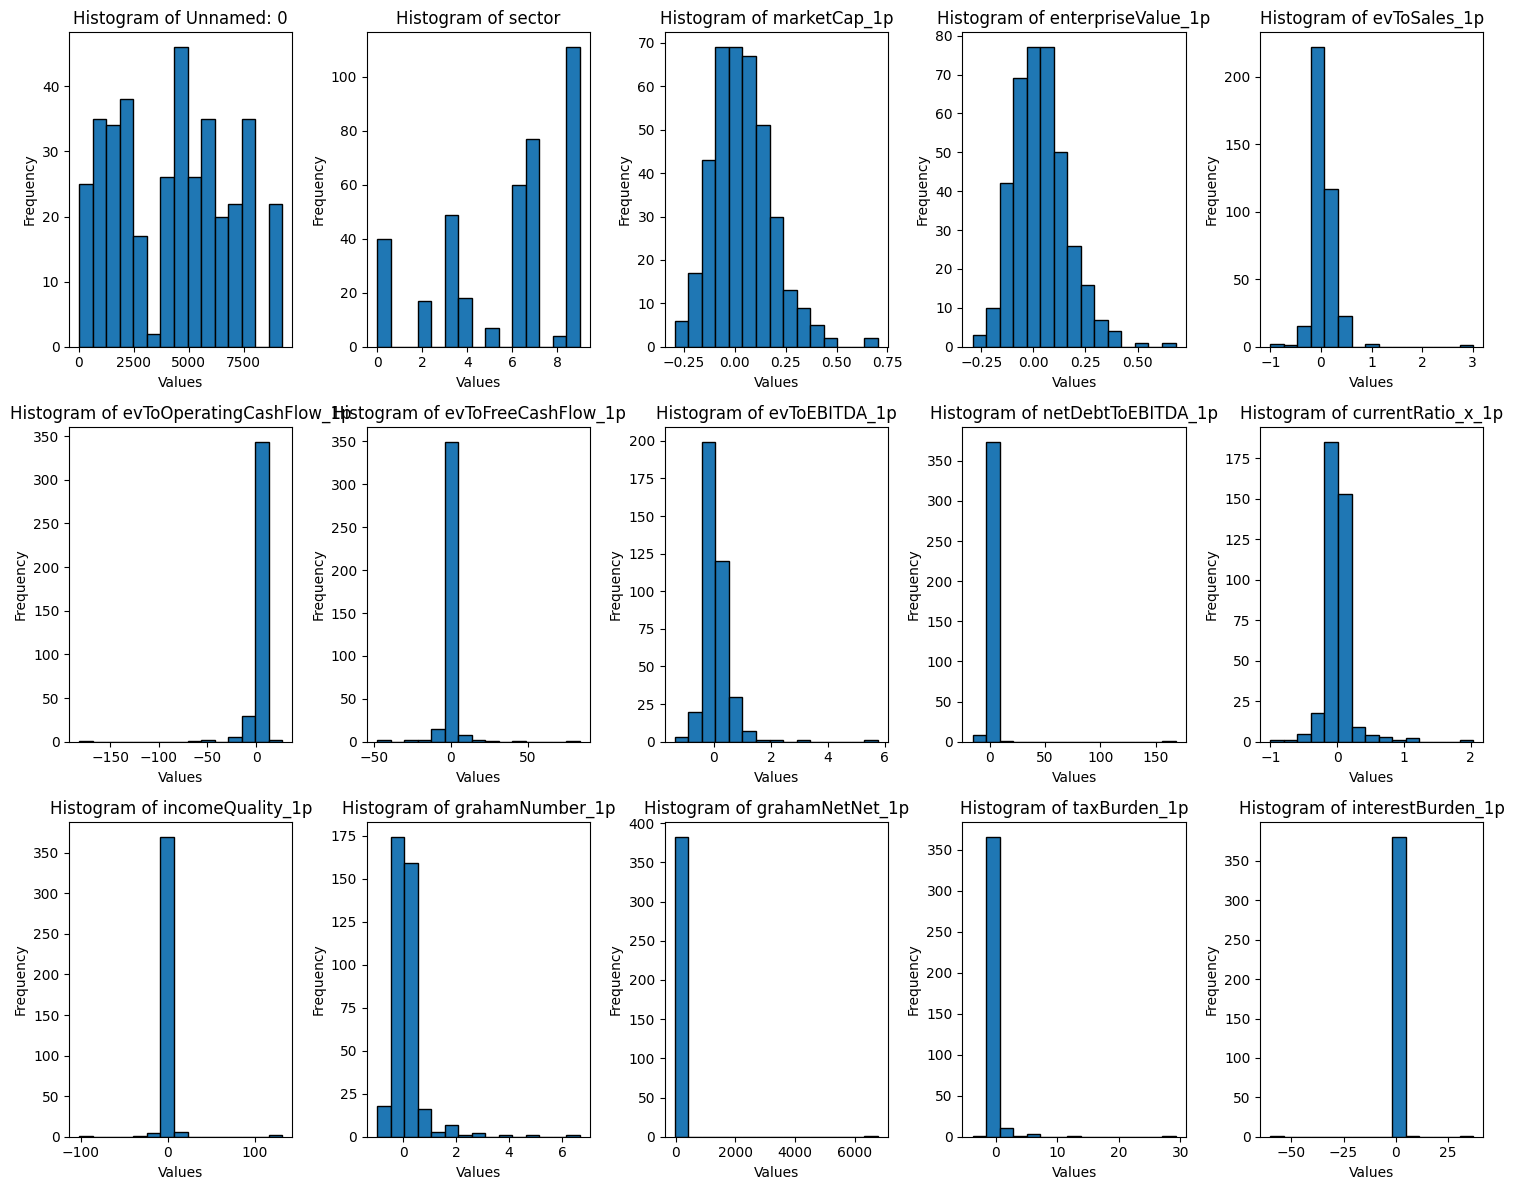

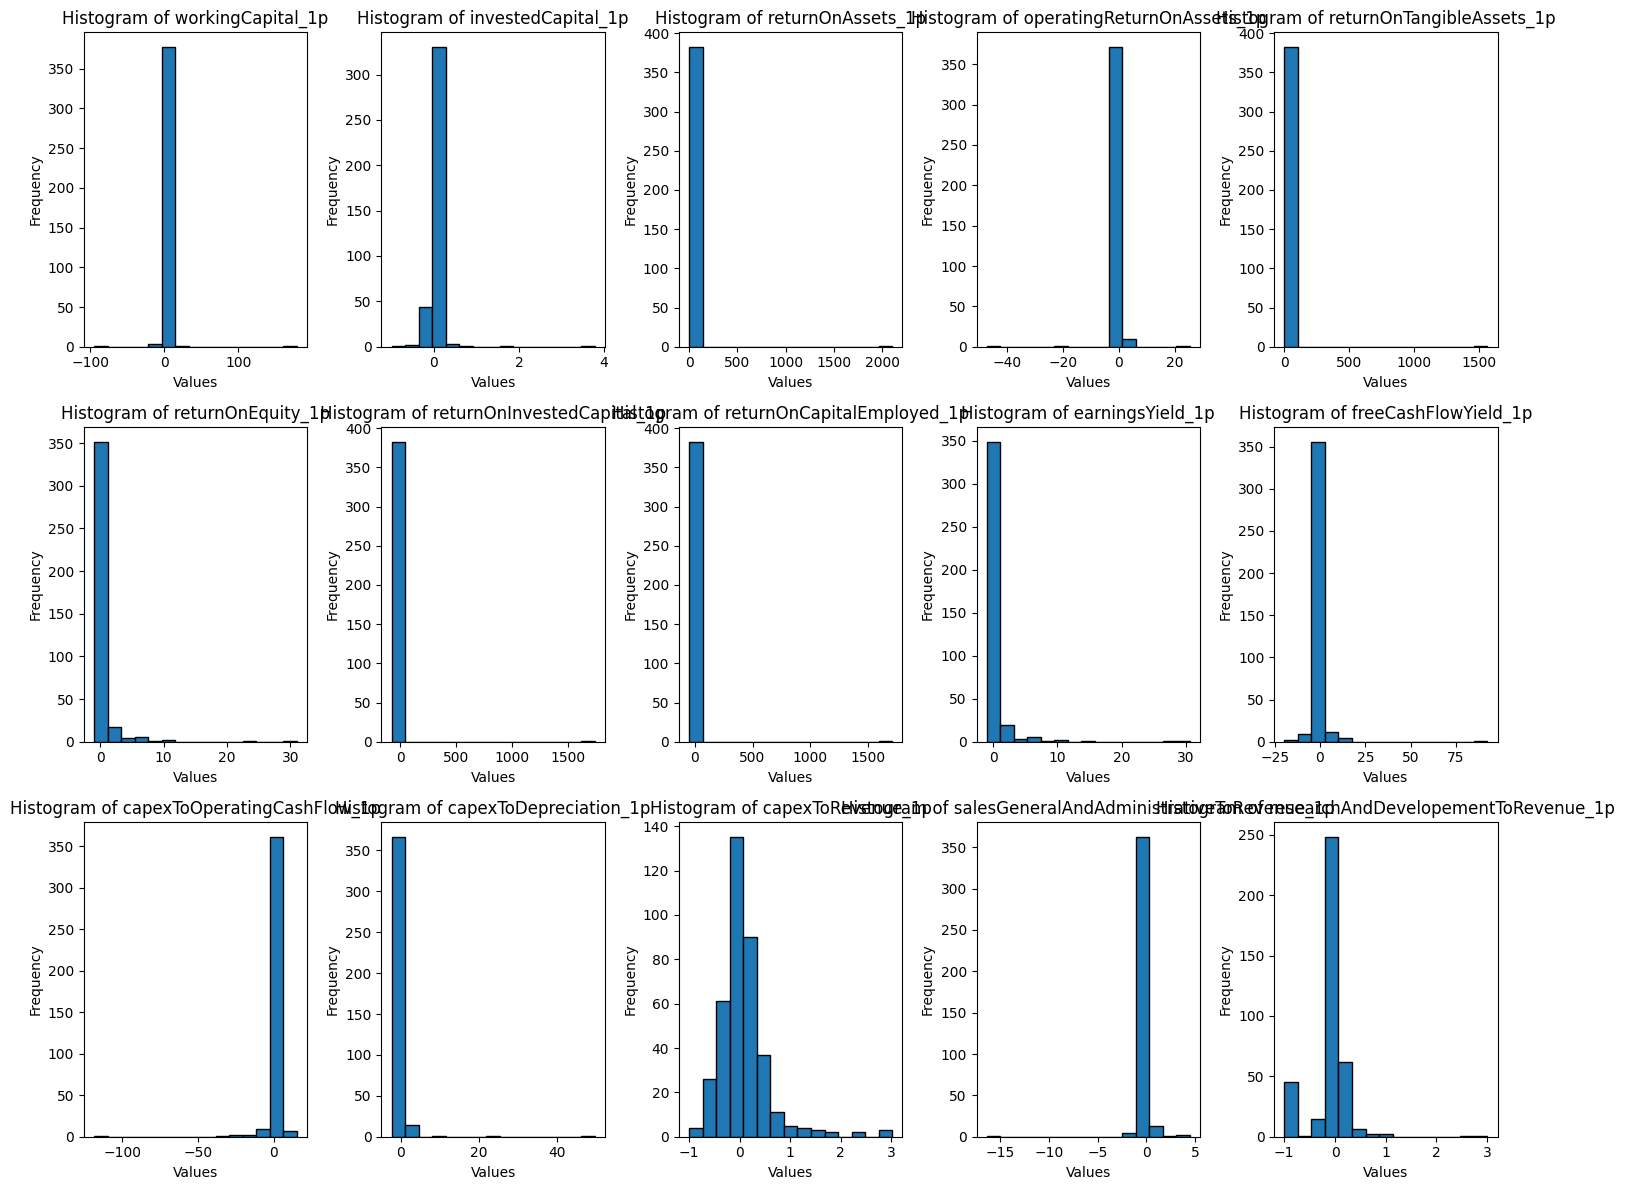

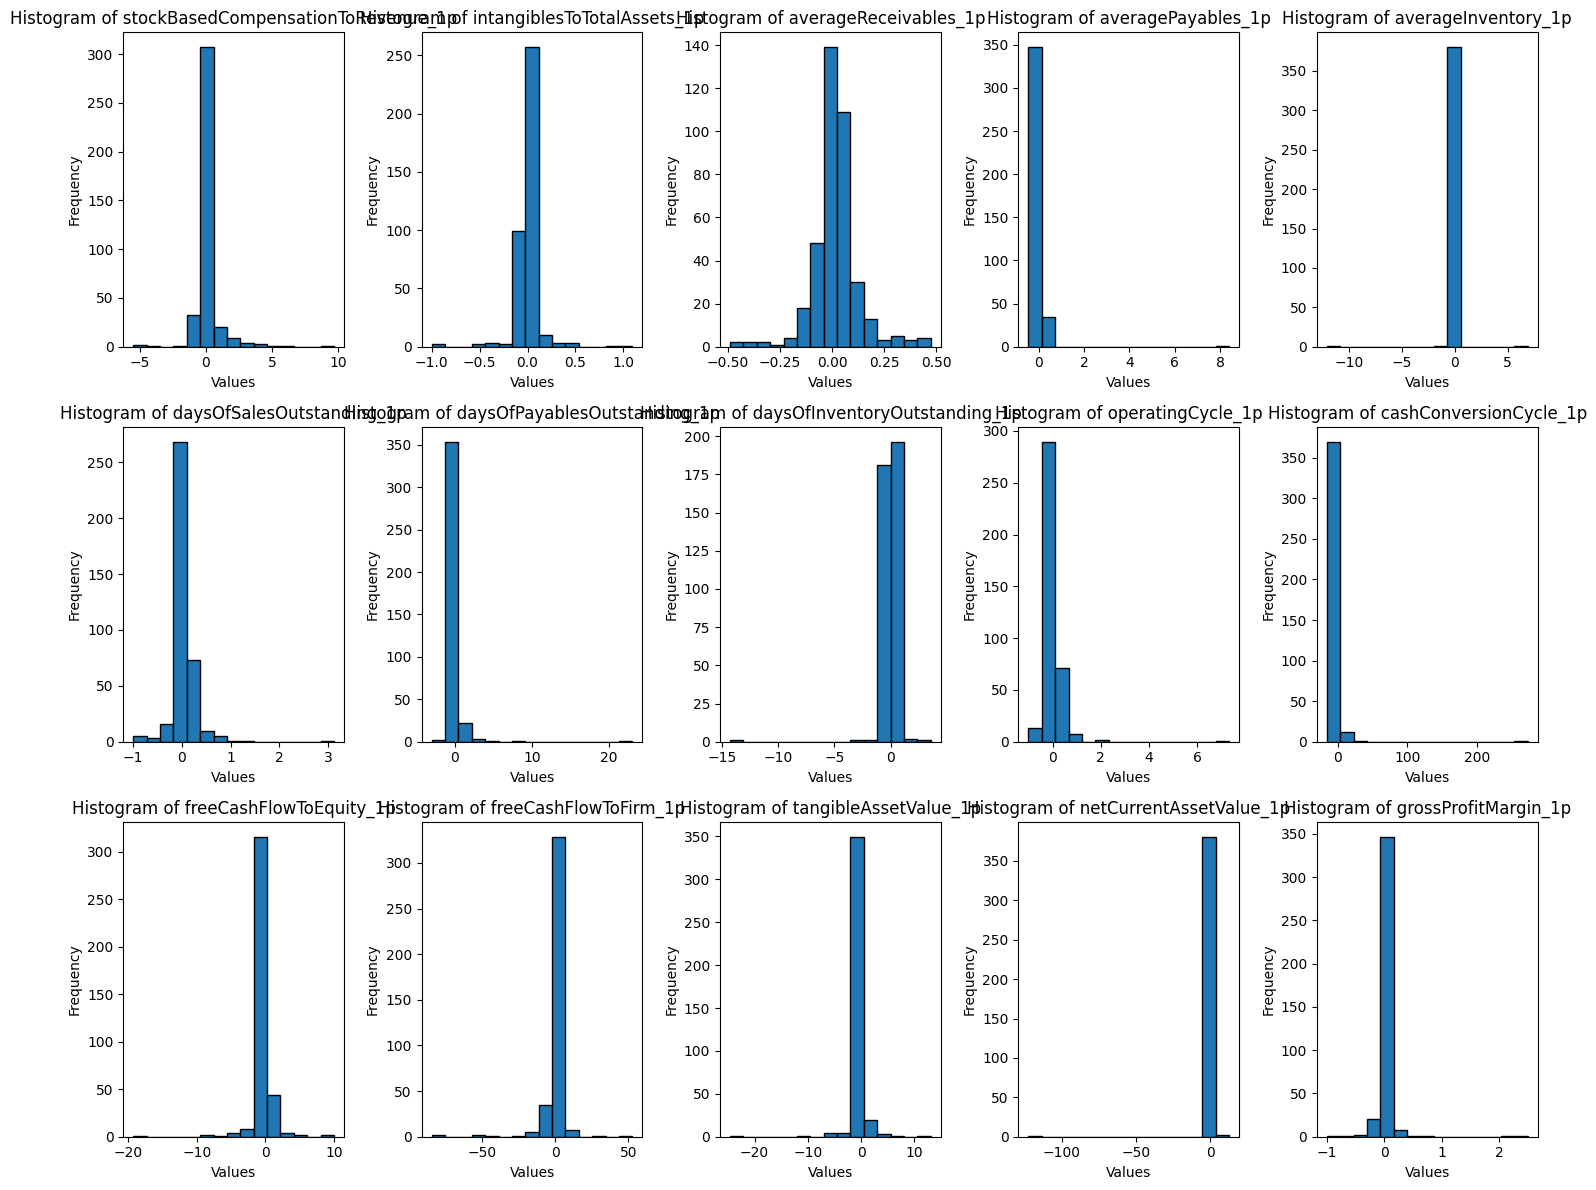

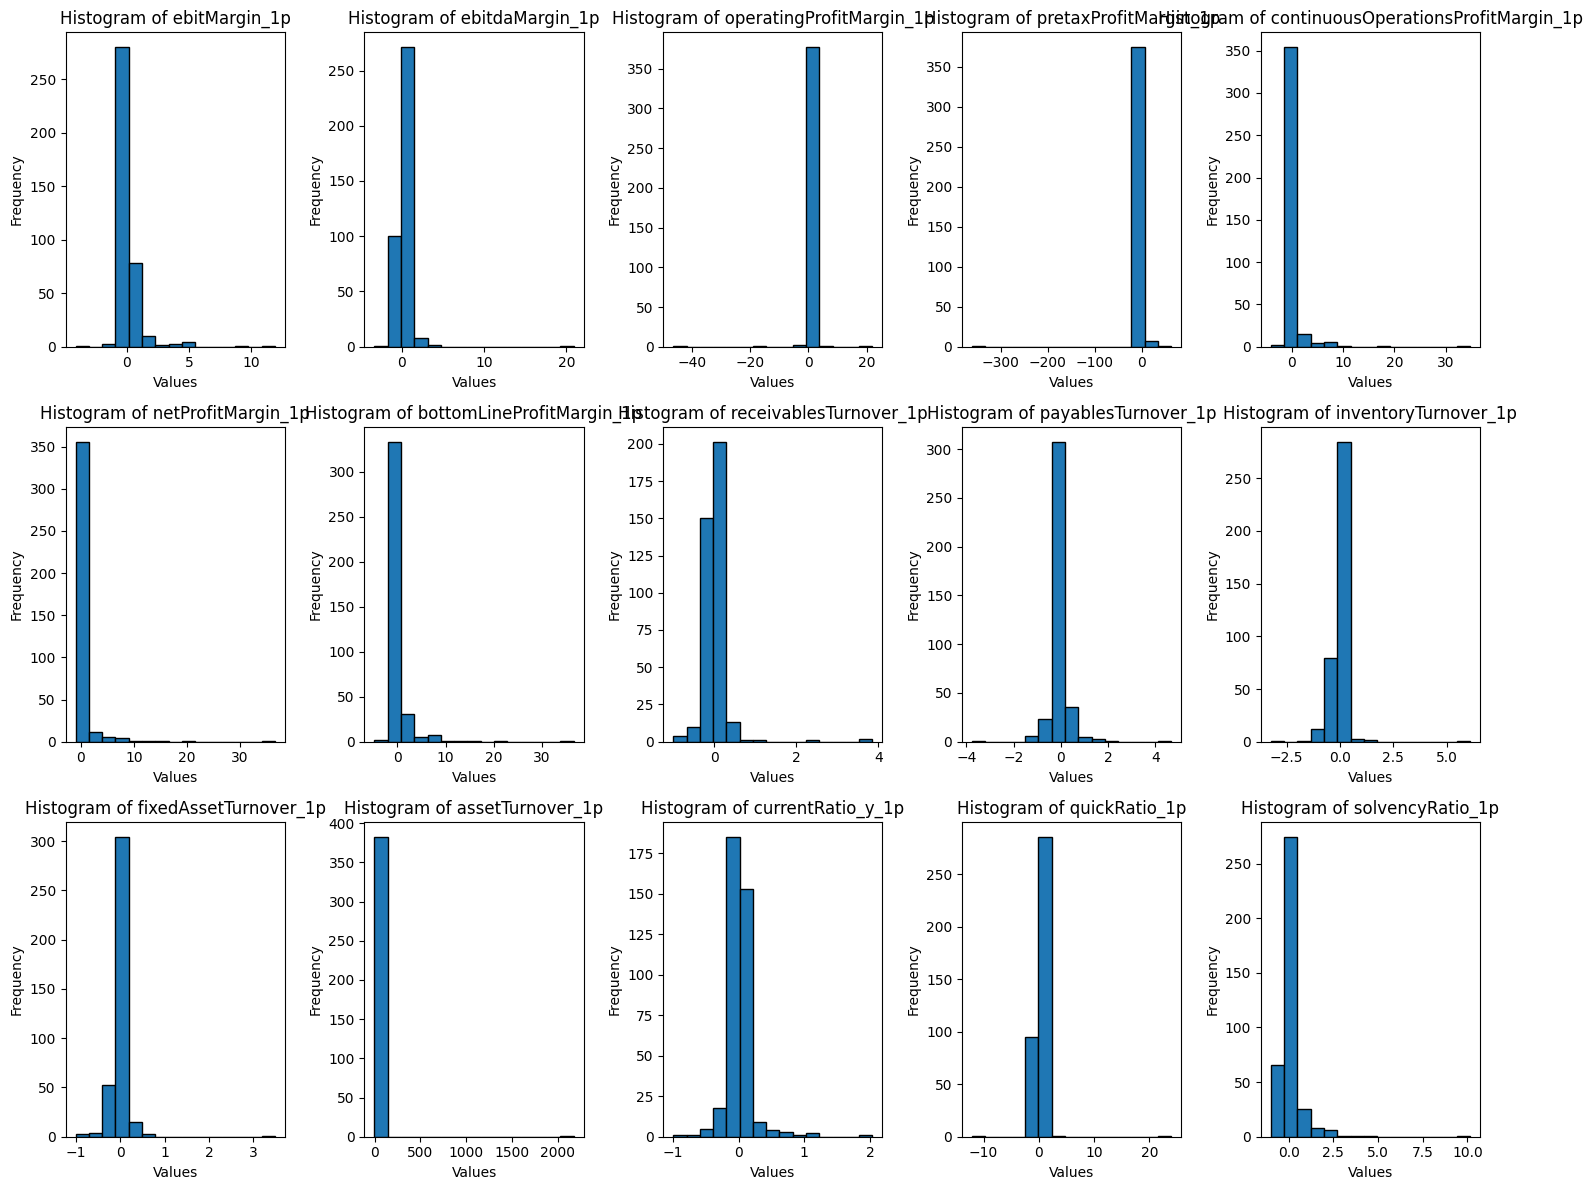

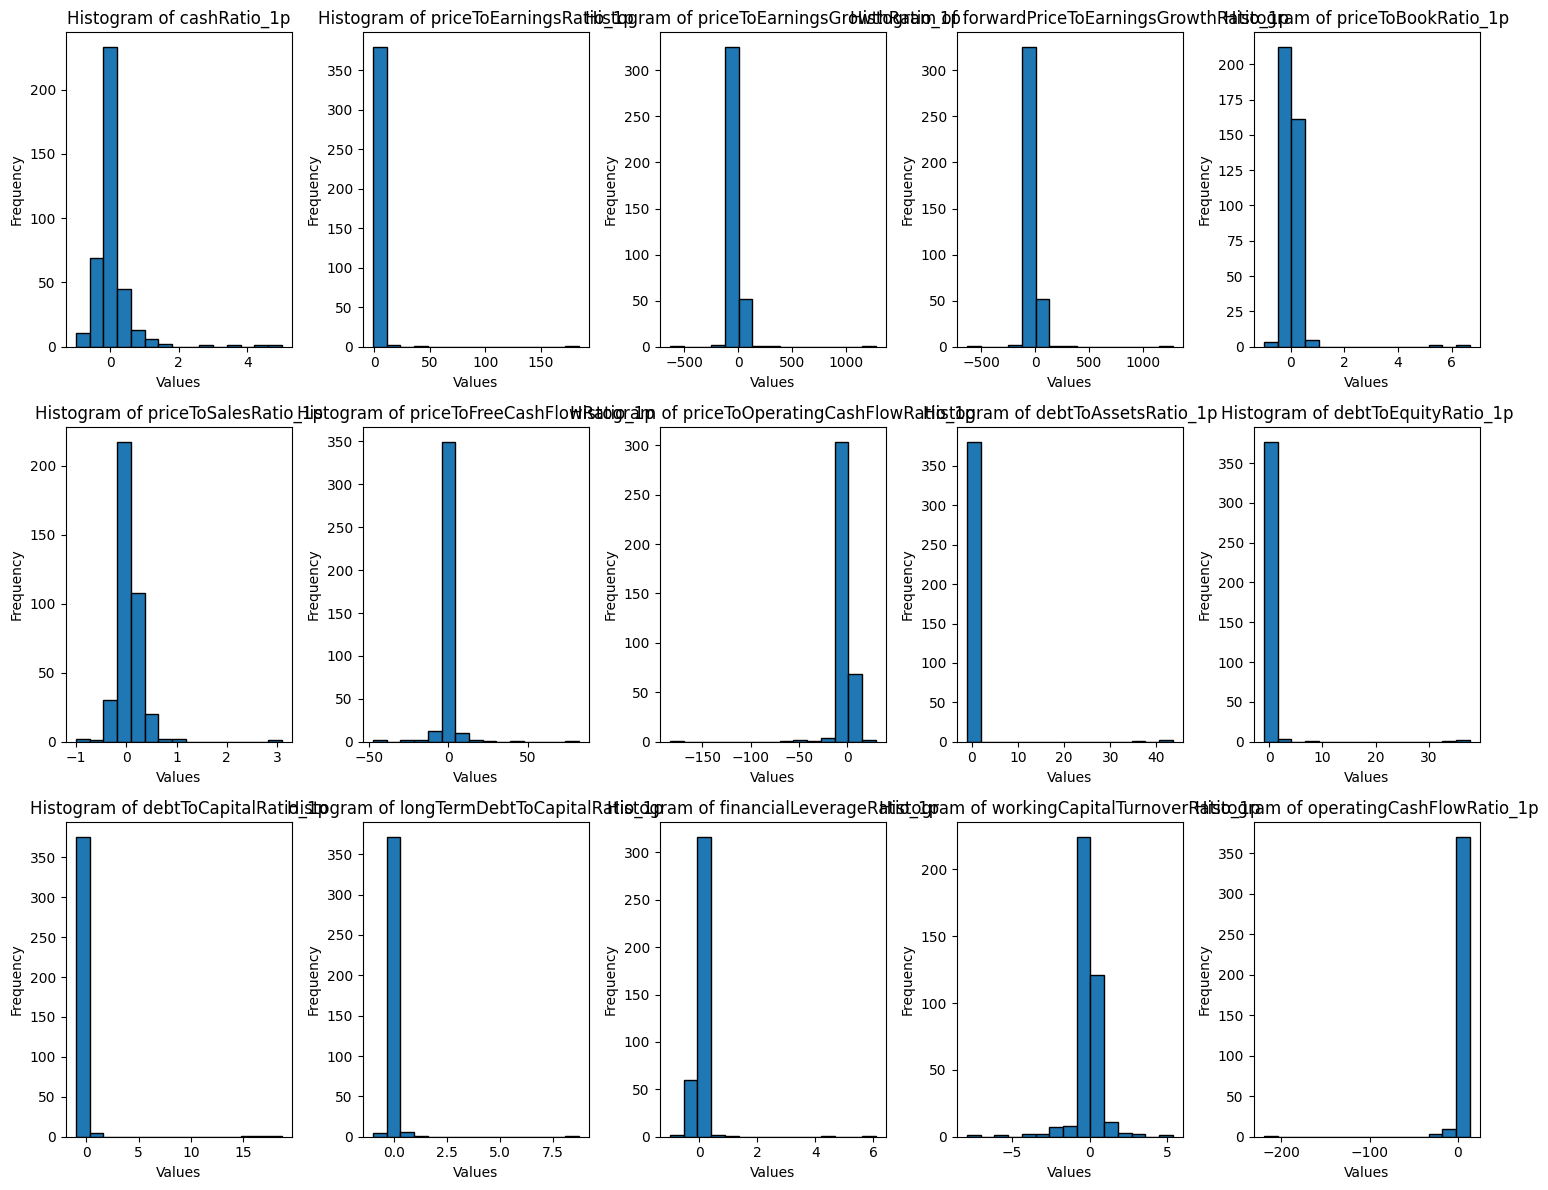

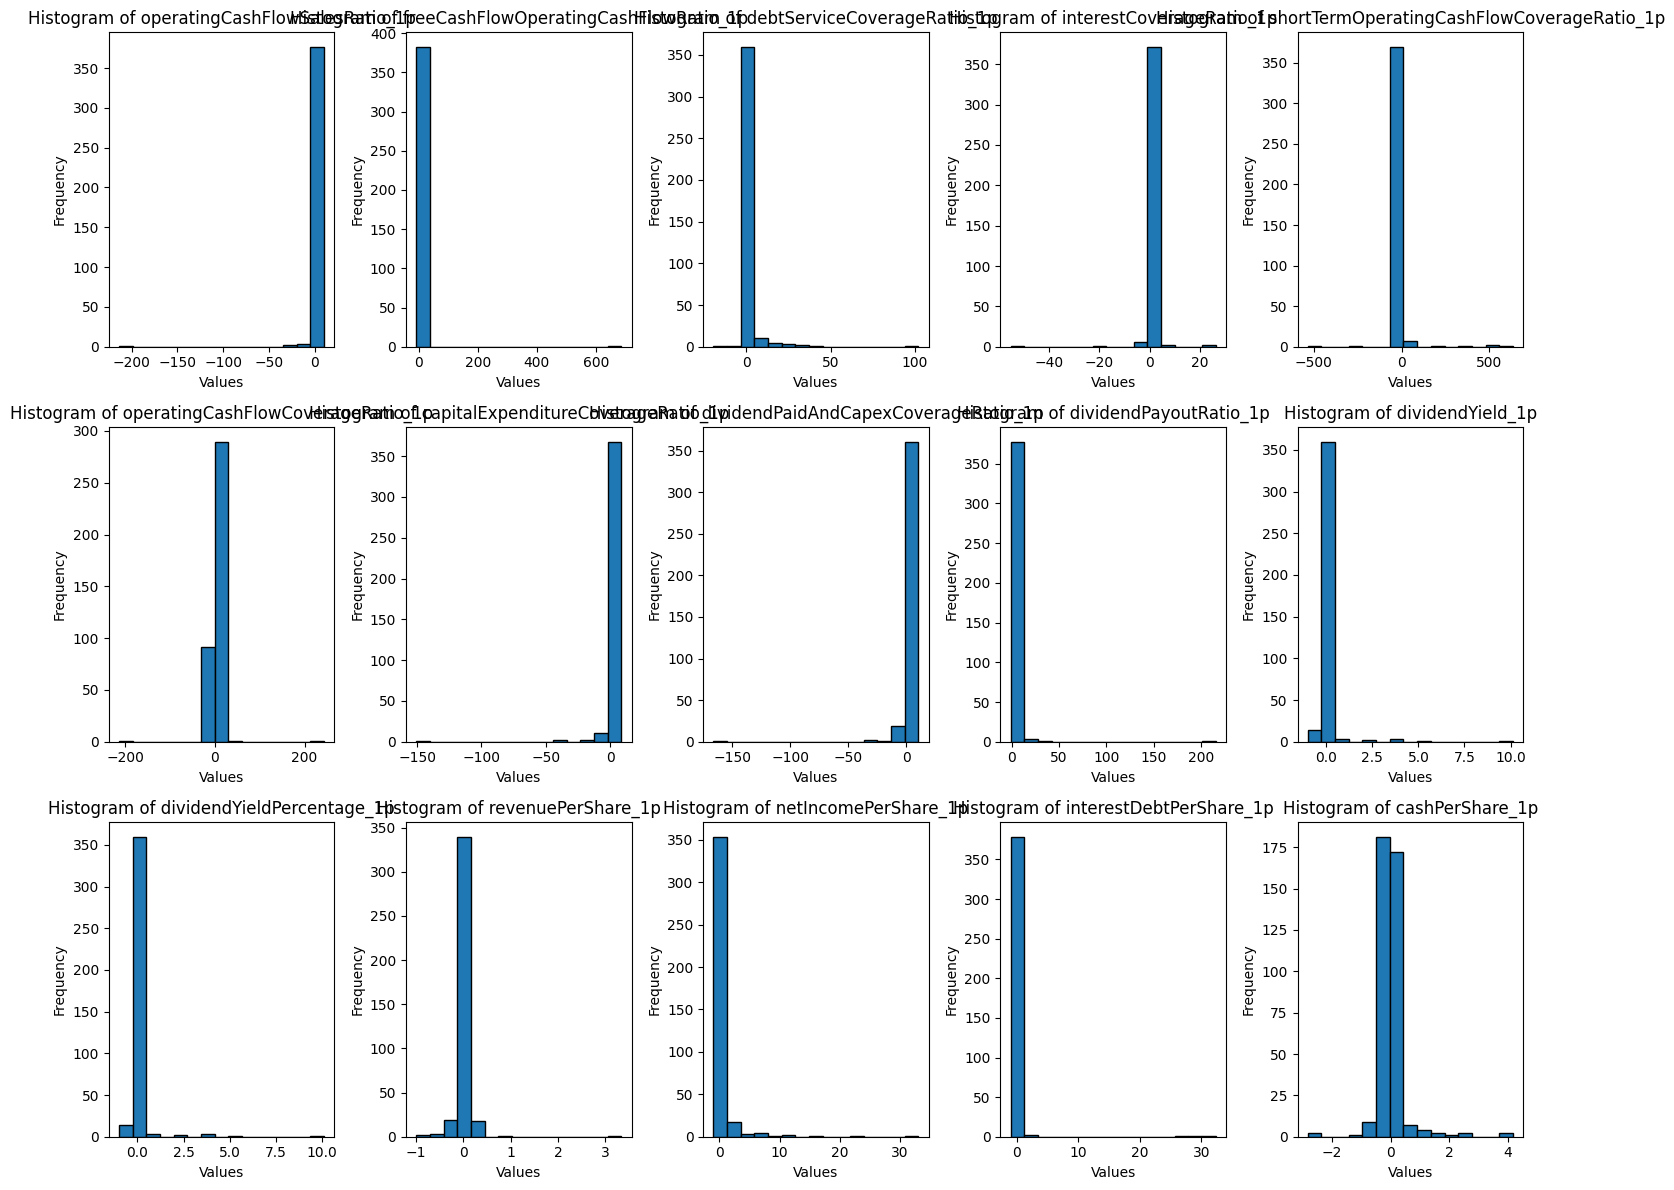

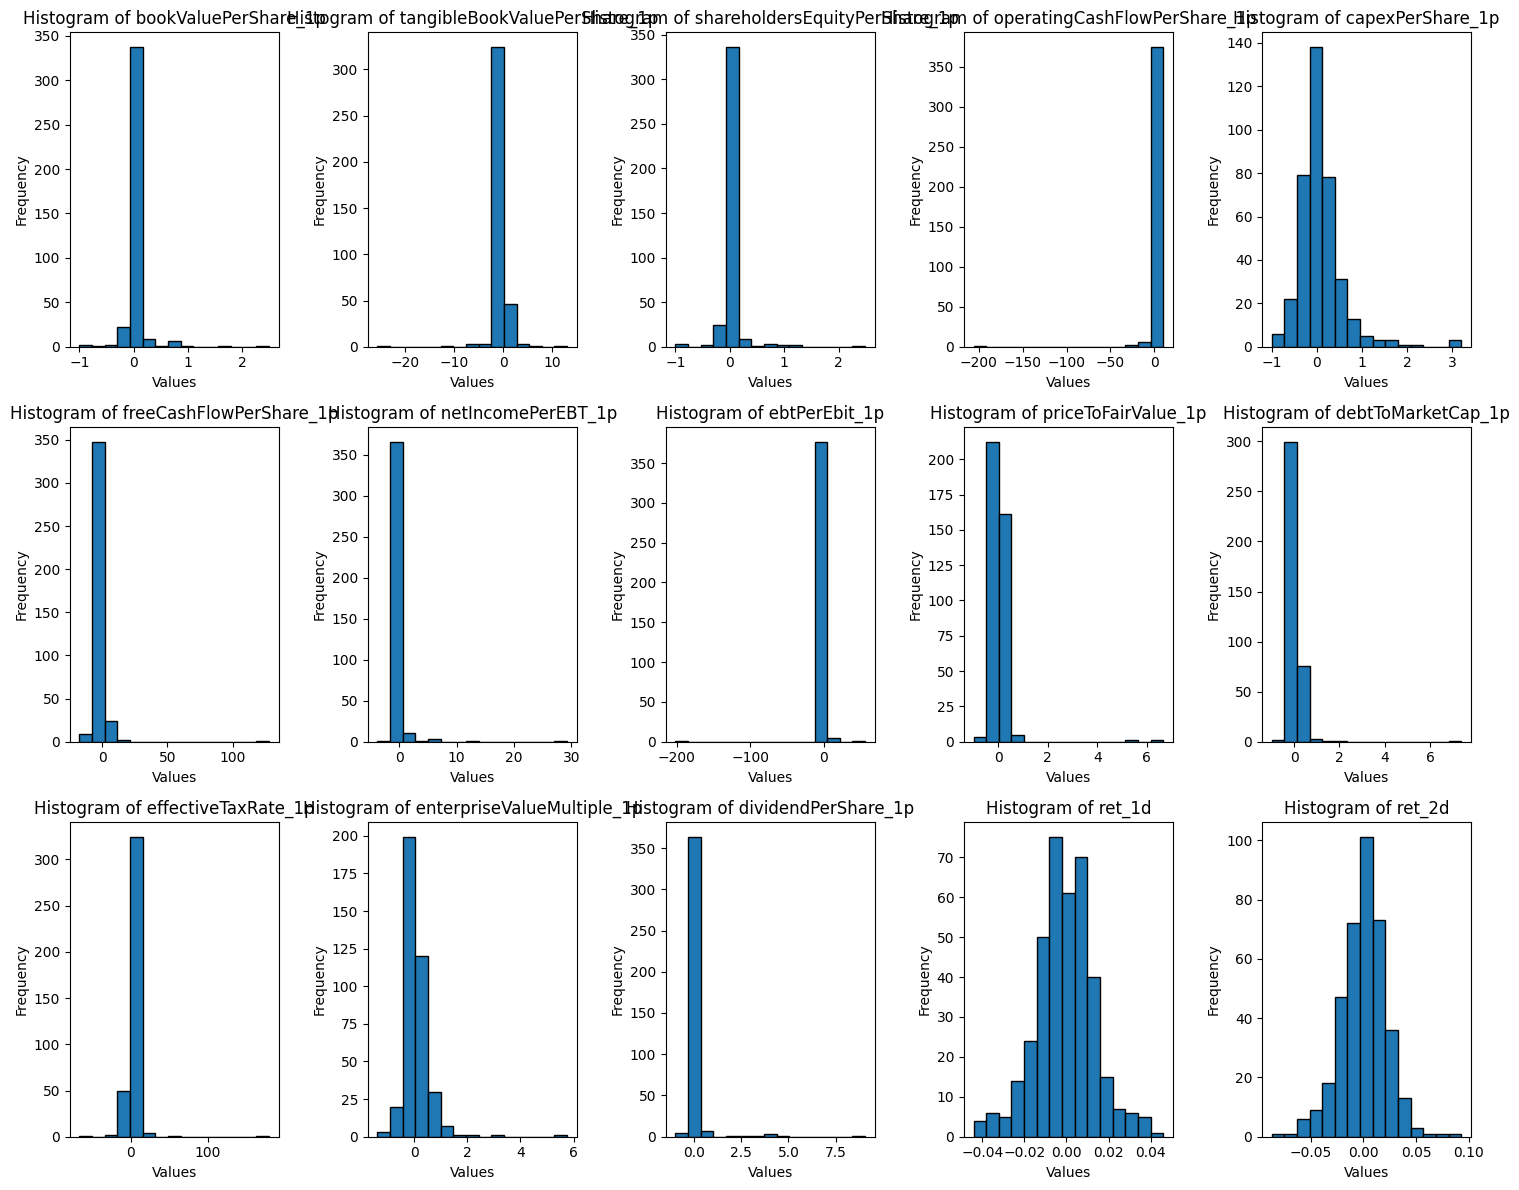

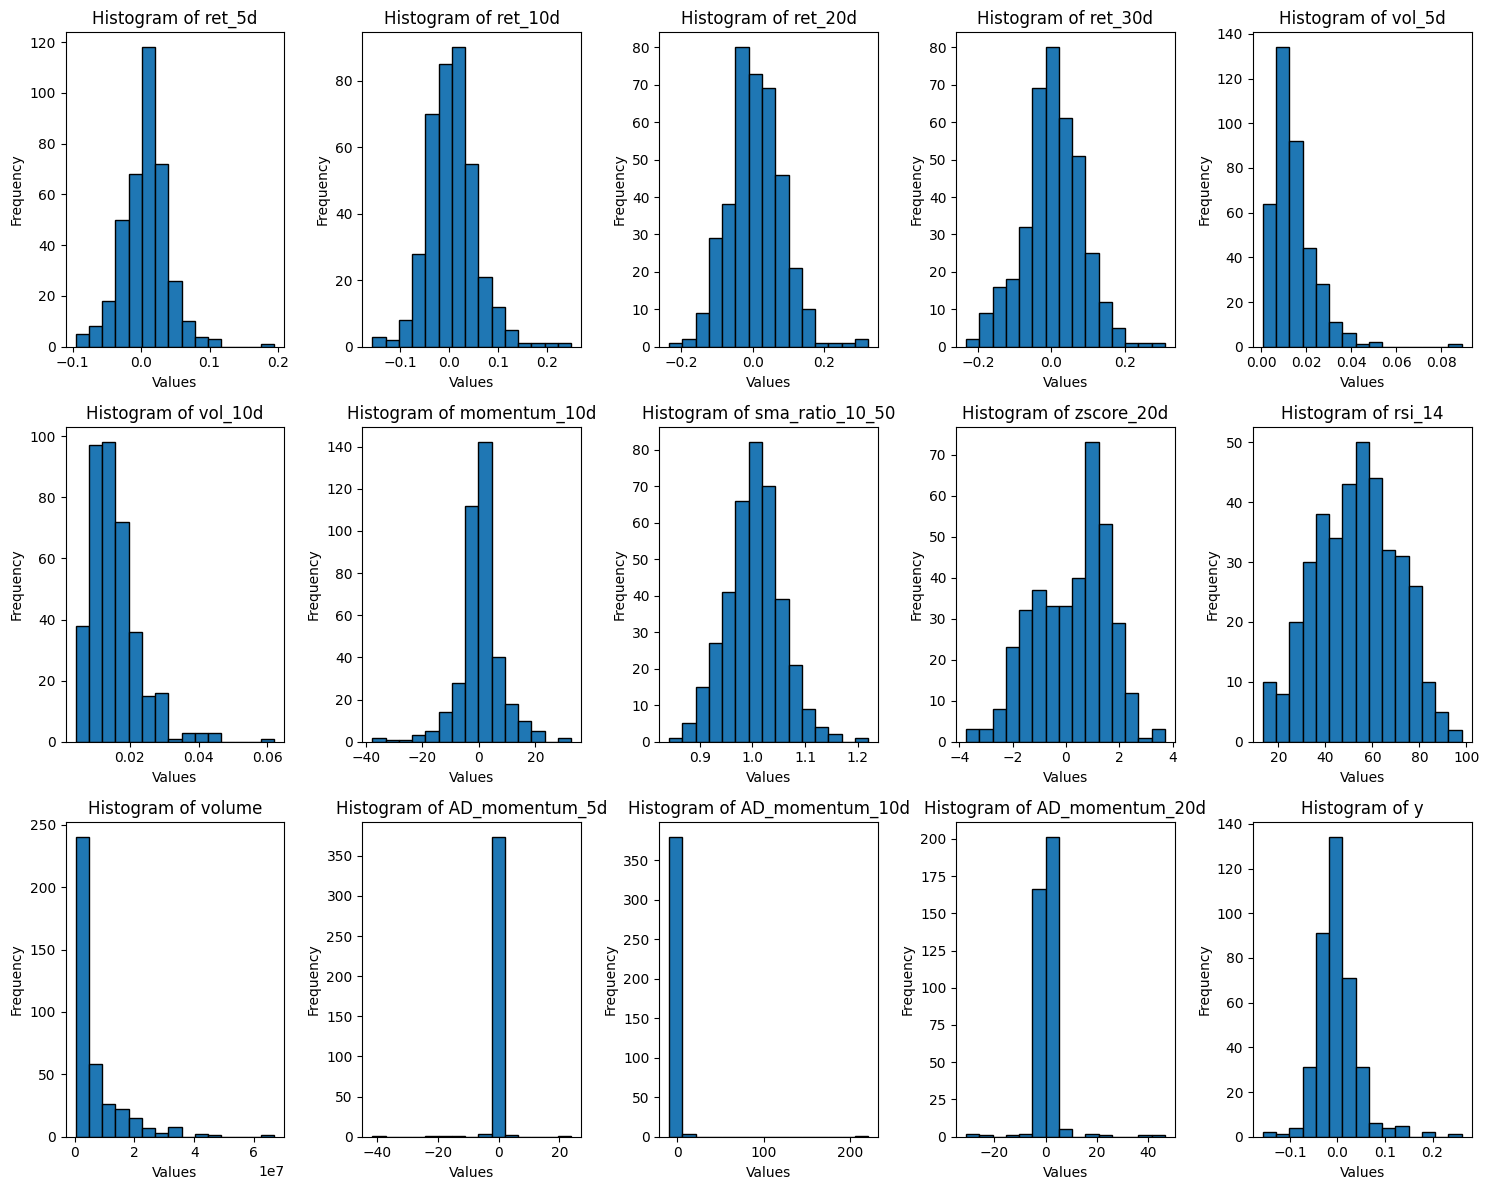

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
df_signals = FolderStructure.read_interim_csv(CSV.DATABASE)
df_signals_imp = df_signals.drop(columns= Signals.STR_COLS)
df_signals_imp.replace([float('inf'), float('-inf')], np.nan, inplace=True)
df_signals_imp.dropna(inplace=True)


# Number of histograms per figure
histograms_per_figure = 12
rows, cols = 4, 3  # Grid size (3x3 for 9 histograms)

# Calculate the number of figures required
num_figures = (len(df_signals_imp.columns) // histograms_per_figure) + (1 if len(df_signals_imp.columns) % histograms_per_figure != 0 else 0)

# Loop through and create figures with 9 histograms each
for fig_num in range(num_figures):
    # Create a new figure
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    axes = axes.flatten()  # Flatten axes to make iteration easier
    
    # Get the columns to plot in this figure (chunk of 9 columns)
    start_idx = fig_num * histograms_per_figure
    end_idx = min((fig_num + 1) * histograms_per_figure, len(df_signals_imp.columns))
    columns_to_plot = df_signals_imp.columns[start_idx:end_idx]
    
    # Loop through each column in the chunk and plot its histogram
    for i, col in enumerate(columns_to_plot):
        axes[i].hist(df_signals_imp[col], bins=15, edgecolor='black')
        axes[i].set_title(f"Histogram of {col}")
        axes[i].set_xlabel('Values')
        axes[i].set_ylabel('Frequency')
    
    # Hide any unused subplots (if there are fewer than 9 columns in the last figure)
    for j in range(len(columns_to_plot), len(axes)):
        axes[j].axis('off')
    
    # Adjust layout to avoid overlap
    plt.tight_layout()
    
    # Show or save the figure
    plt.show()
    # Optionally save the figure
    # plt.savefig(f"histograms_figure_{fig_num+1}.png")
    
    # Close the figure to free up memory
    plt.close()

# Feature Construction
- Need to perform this for Balance Sheet, Income Statement and Historical Stock Price
- Need a way to handle a variety of stocks (ticker feature)

In [ ]:
# Feature Construction
from sklearn.base import BaseEstimator, TransformerMixin

# Need to perform this for Balance Sheet, Income Statement and Historical Stock Price
# SHOULD REPLACE INF by NAn and drop them
class TechnicalIndicatorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X): # X are the fundamental values needed to calculate all the other features
        df = X.copy()
        
        # Create many features inside one transformer
        df['sma_10'] = df['close'].rolling(10).mean()
        df['sma_50'] = df['close'].rolling(50).mean()
        df['rsi'] = compute_rsi(df['close'])
        df['macd'] = compute_macd(df['close'])
        df['lag_1'] = df['close'].shift(1)
        df['volatility'] = df['close'].rolling(10).std()
        # ... up to 140 features

        return df # handle NaNs from rolling/shift

# Data Cleaning + PreProcessing
- NaN values will be dropped

In [ ]:
from sklearn.pipeline import FeatureUnion, Pipeline

transformer1 = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
])

transformer2 = Pipeline([
    ('pca', PCA(n_components=5))
])


NameError: name 'SimpleImputer' is not defined

# Feature Ranking